In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_cleaning import fetch_and_clean

sns.set_theme(style='whitegrid')
df = fetch_and_clean()
df.head()

Raw shape: (1896, 11)
Missing ratings: 735
Cleaned shape: (1896, 14)


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time,is_rated,is_weekend,cost_bucket,is_fast_delivery
0,1476547,83095,Bareburger,American,6.84,Weekend,5.0,22,24,46,1,1,Low,0
1,1476548,122609,Blue Ribbon Sushi,Japanese,6.84,Weekend,4.0,20,30,50,1,1,Low,0
2,1476549,75169,Tamarind TriBeCa,Indian,6.74,Weekend,5.0,25,26,51,1,1,Low,0
3,1476550,101347,The Loop,Japanese,16.98,Weekend,5.0,26,27,53,1,1,Medium,0
4,1476551,49034,The Smile,American,12.18,Weekend,4.0,22,27,49,0,1,Low,0


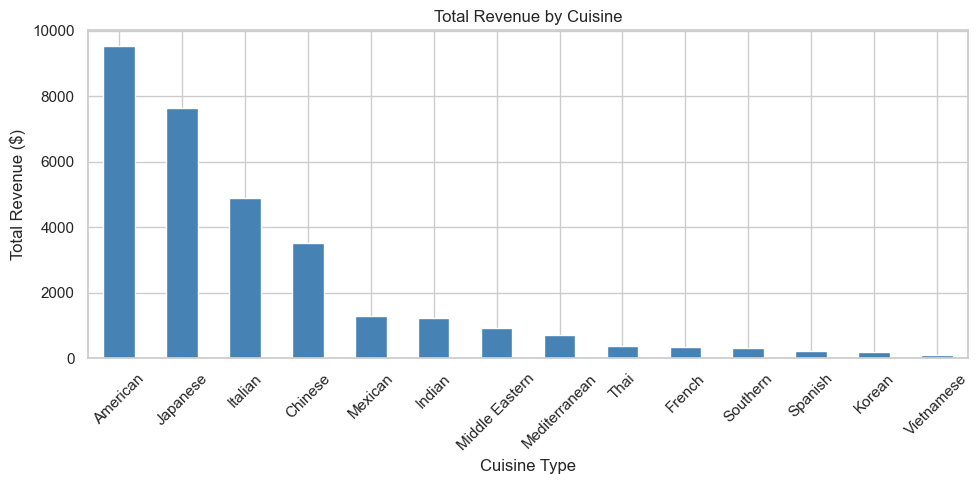

In [3]:
# Revenue by cuisine
revenue = (
    df.groupby('cuisine_type')['cost_of_the_order']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
revenue.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Revenue by Cuisine')
ax.set_xlabel('Cuisine Type')
ax.set_ylabel('Total Revenue ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart1_revenue_by_cuisine.png', dpi=150)
plt.show()

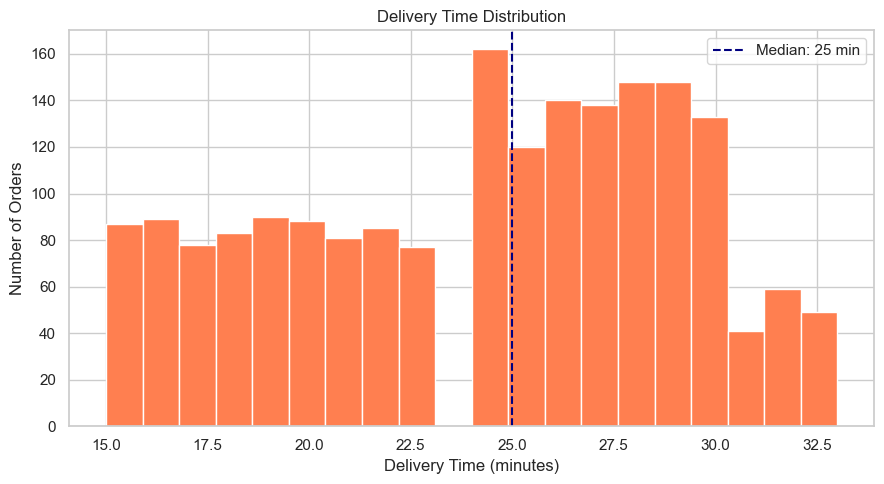

In [4]:
# Delivery time distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['delivery_time'].dropna(), bins=20, color='coral', edgecolor='white')
ax.axvline(df['delivery_time'].median(), color='navy', linestyle='--', label=f"Median: {df['delivery_time'].median():.0f} min")
ax.set_title('Delivery Time Distribution')
ax.set_xlabel('Delivery Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart2_delivery_time_distribution.png', dpi=150)
plt.show()

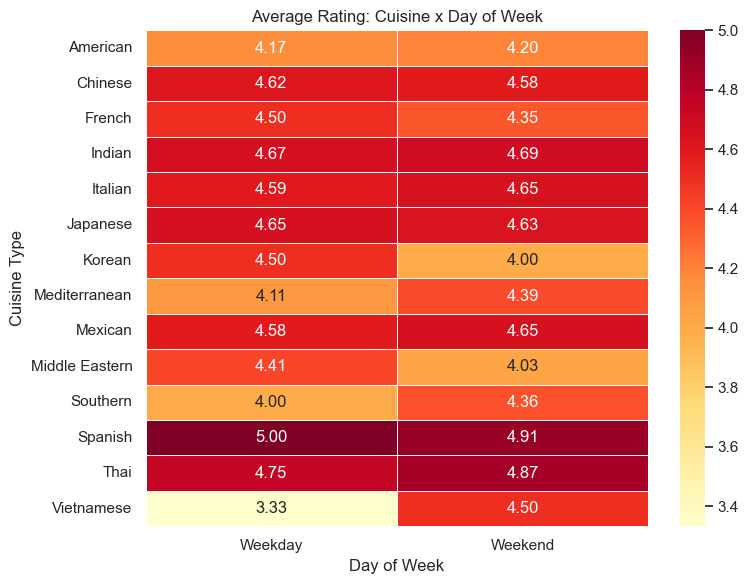

In [5]:
# Rating heatmap — cuisine x day of week
heatmap_data = (
    df.groupby(['cuisine_type', 'day_of_the_week'])['rating']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Average Rating: Cuisine x Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Cuisine Type')
plt.tight_layout()
plt.savefig('../outputs/chart3_rating_heatmap.png', dpi=150)
plt.show()

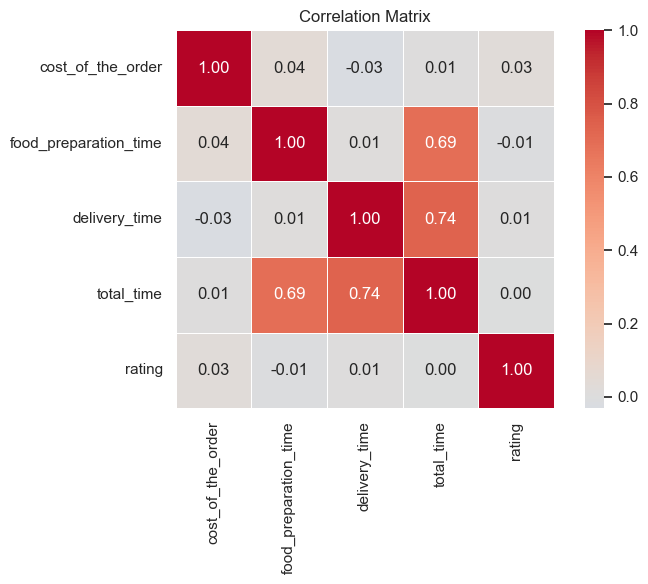

In [6]:
# Correlation matrix
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'total_time', 'rating']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/chart4_correlation_matrix.png', dpi=150)
plt.show()